In [168]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import getpass
import os
import random
import re
import tarfile
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.utils as utils
import torchvision.transforms as transforms
import pandas as pd
import seaborn as sns
from collections import Counter
import torchvision.models as models
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm
from IPython.display import clear_output
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from torchvision.transforms import v2 as T2
from torchvision.transforms.v2 import functional as F
from torchvision.tv_tensors import BoundingBoxes
from torchvision.tv_tensors import Image as TVImage
from PIL import Image as PILImage
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models import mobilenet_v3_small

In [169]:
BASE_DIR = r"C:\Users\sophi\image\iapr2025\images\robo"

TRAIN_ANNOTATIONS_CSV = os.path.join(BASE_DIR, "train_annotations.csv")
VAL_ANNOTATIONS_CSV = os.path.join(BASE_DIR, "valid_annotations.csv")
IMAGE_DIR_TRAIN = os.path.join(BASE_DIR, "train")
IMAGE_DIR_VAL = os.path.join(BASE_DIR, "valid")
TEST_IMAGE_DIR = r'C:\Users\sophi\image\iapr2025\project\images\train_robo_1\test'

BATCH_SIZE = 10
EPOCHS = 3
LEARNING_RATE = 0.001
NUM_CLASSES = 13
INPUT_SIZE = 224

# CSV_PATH = 'C:\Users\sophi\image\iapr2025\chocolate-recognition-ml\dataset_project_iapr2025\train.csv'

grid_size = 7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [170]:
classes = ("Jelly White", "Jelly Milk", "Jelly Black", "Amandina", "Creme brulee", "Triangolo", "Tentation noir",
           "Comtesse", "Noblesse", "Noir authentique", "Passion au lait", "Arabia", "Stracciatella")

In [171]:
class ChocolateDetectionDataset(Dataset):
    def __init__(self, csv_path, image_dir, classes, image_size = (224,224), transform=None):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.image_size = image_size
        self.transform = transform

        # Group annotations by image
        self.image_data = self.df.groupby('filename')
        self.image_filenames = list(self.image_data.groups.keys())

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        records = self.image_data.get_group(img_name)

        # Load image
        img_path = os.path.join(self.image_dir, img_name)
        image = PILImage.open(img_path).convert("RGB")
        
        boxes = records[['xmin', 'ymin', 'xmax', 'ymax']].values
        boxes = torch.tensor(boxes, dtype=torch.float32)

        # bounding box needs to be a torchvision BoundingBoxes object
        boxes = BoundingBoxes(boxes, format="XYXY", canvas_size=image.size[::-1])  # PIL: (W, H)

        labels = torch.tensor([self.class_to_idx[row["class"]] for _, row in records.iterrows()], dtype=torch.int64)    
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        if self.transform:
            # image, target = self.transform(image, target)
            sample = {"image": image, "target": target}
            sample = self.transform(sample)
            image = sample["image"]
            target = sample["target"]
    
        return image, target


In [172]:
normalize = T2.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

transform = T2.Compose([
    T2.ToImage(),
    T2.Resize((224,224)),
    T2.ToDtype(torch.float32, scale=True),
    normalize,
])

train_dataset = ChocolateDetectionDataset(
    csv_path=r"C:\Users\sophi\image\iapr2025\project\images\robo\train_annotations.csv",
    image_dir=r"C:\Users\sophi\image\iapr2025\project\images\robo\train",
    classes=classes,
    transform=transform
)

val_dataset = ChocolateDetectionDataset(
    csv_path=r"C:\Users\sophi\image\iapr2025\project\images\robo\valid_annotations.csv",
    image_dir=r"C:\Users\sophi\image\iapr2025\project\images\robo\valid",
    classes=classes,
    transform=transform
)

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)


In [173]:
# Visualization of images
def plot_images_from_dataset(images, targets):
    batch_size = len(images)
    fig = plt.figure(figsize=(12, 12))
    for idx in range(batch_size):
        img = images[idx].numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
        img = np.clip(img, 0, 1)

        ax = fig.add_subplot(3, int(np.ceil(batch_size / 3)), idx + 1)
        ax.imshow(img)
        ax.axis('off')

        boxes = targets[idx]['boxes']
        labels = targets[idx]['labels']

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, classes[label], color='red', fontsize=8, weight='bold')

    plt.tight_layout()
    plt.show()

# Load one batch
dataiter = iter(train_dataloader)
images, targets = next(dataiter)

# Visualize
# plot_images_from_dataset(images, targets)


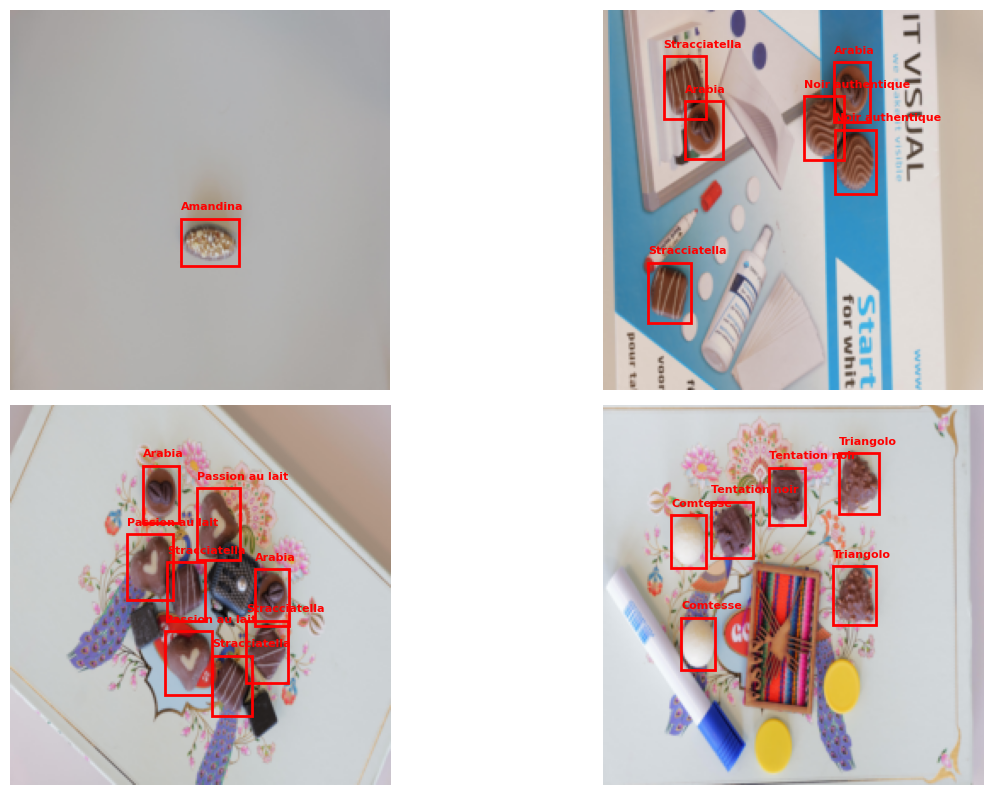

In [174]:
plot_images_from_dataset(*next(iter(train_dataloader)))

In [175]:
def f1(preds, target):
    return f1_score(target, preds, average='macro')

def acc(preds, target):
    return accuracy_score(target, preds)

In [176]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torchvision.models import mobilenet_v3_small

# class CustomRCNN(nn.Module):
#     def __init__(self, num_classes=14):
#         super().__init__()
#         # Backbone CNN (MobileNetV3-small features)
#         backbone = mobilenet_v3_small(pretrained=False)
#         self.backbone = backbone.features
#         self.out_channels = 576  # MobileNetV3 small output channels

#         # ROI Pooler simulation (just adaptive pooling on full image feature map for now)
#         self.roi_pool = nn.AdaptiveMaxPool2d((7, 7))

#         # Classification Head
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(self.out_channels * 7 * 7, 256),
#             nn.ReLU(),
#             nn.Linear(256, num_classes)
#         )

#         # Bounding Box Regressor Head
#         self.box_regressor = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(self.out_channels * 7 * 7, 128),
#             nn.ReLU(),
#             nn.Linear(128, 4)  # x1, y1, x2, y2 offsets
#         )

#     def forward(self, images, targets=None):
#         # images: List[Tensor] of shape [C, H, W]
#         # targets: List[Dict] with keys 'boxes', 'labels'

#         features = [self.backbone(img.unsqueeze(0)) for img in images]

#         losses = {}
#         results = []

#         for feat, img in zip(features, images):
#             pooled_feat = self.roi_pool(feat)

#             # Predict class logits & bounding box offsets
#             class_logits = self.classifier(pooled_feat)
#             bbox_deltas = self.box_regressor(pooled_feat)

#             if self.training and targets is not None:
#                 # Dummy Loss Computation (replace with real IoU-based loss later)
#                 gt_labels = targets[0]['labels'][0]  # Dummy, assumes 1 object
#                 gt_box = targets[0]['boxes'][0]      # Dummy, assumes 1 object

#                 # Classification Loss (CrossEntropy)
#                 loss_cls = F.cross_entropy(class_logits, gt_labels.unsqueeze(0))

#                 # Box Regression Loss (L1 Loss for now)
#                 loss_box = F.l1_loss(bbox_deltas.squeeze(0), gt_box)

#                 losses['loss_classifier'] = loss_cls
#                 losses['loss_box_reg'] = loss_box
#                 return losses

#             else:
#                 # Inference Mode: Return fake detections
#                 result = {
#                     'boxes': bbox_deltas.squeeze(0).unsqueeze(0),  # shape [1, 4]
#                     'labels': torch.argmax(class_logits, dim=1),
#                     'scores': torch.softmax(class_logits, dim=1).max(dim=1).values
#                 }
#                 results.append(result)

#         return results if not self.training else losses


# # Example usage
# num_classes = 14  # 13 chocolates + 1 background
# model = CustomRCNN()

# # Count parameters
# total_params = sum(p.numel() for p in model.parameters())
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# print(f"Total Parameters: {total_params/1e6:.2f}M")
# print(f"Trainable Parameters: {trainable_params/1e6:.2f}M")

In [195]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# class Net(nn.Module):
#     def __init__(self):
#         super().__init__()
#         import torchvision

#         NUM_CLASSES = 14  # 13 classes + background

#         # self.model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=False)
#         # self.model = torchvision.models.detection.fasterrcnn_resnet18_fpn(pretrained=False)
#         self.model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(pretrained=False)
#         # in_features = self.model.roi_heads.box_predictor.cls_score.in_features
#         # self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

#         # to reduce the computational complexity we reduce the size and number of hidden layers
#         # self.model.classifier = nn.Sequential(
#         #     nn.Dropout(p=0.35, inplace=False),
#         #     nn.Linear(in_features=9216, out_features=128, bias=True),
#         #     nn.ReLU(inplace=True),
#         #     nn.Linear(in_features=128, out_features=10, bias=True)
#         # )

#     def freeze_feature_layers(self):
#         # freeze the feature extraction part
#         for param in self.model.backbone.body.parameters():
#             param.requires_grad = False

#     def forward(self, images, targets=None):
#         if self.training:
#             return self.model(images, targets)  # returns losses during training
#         else:
#             return self.model(images)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.faster_rcnn import TwoMLPHead, FastRCNNPredictor

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        import torchvision

        NUM_CLASSES = 14  # 13 classes + background

        self.model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=False)
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

        in_features = self.model.roi_heads.box_head.fc6.in_features
        self.model.roi_heads.box_head = TwoMLPHead(in_features, 256)
        self.model.roi_heads.box_predictor = FastRCNNPredictor(256, NUM_CLASSES)
        # Reduce RPN proposals
        self.model.rpn.post_nms_top_n_train = 100
        self.model.rpn.post_nms_top_n_test = 50

        # to reduce the computational complexity we reduce the size and number of hidden layers
        # self.model.classifier = nn.Sequential(
        #     nn.Dropout(p=0.35, inplace=False),
        #     nn.Linear(in_features=9216, out_features=128, bias=True),
        #     nn.ReLU(inplace=True),
        #     nn.Linear(in_features=128, out_features=10, bias=True)
        # )

    def freeze_feature_layers(self):
        # freeze the feature extraction part
        for param in self.model.backbone.body.parameters():
            param.requires_grad = False

    def forward(self, images, targets=None):
        if self.training:
            return self.model(images, targets)  # returns losses during training
        else:
            return self.model(images)

In [178]:
# Example usage
num_classes = 14  # 13 chocolates + 1 background
model = Net()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params/1e6:.2f}M")
print(f"Trainable Parameters: {trainable_params/1e6:.2f}M")

c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Total Parameters: 5.20M
Trainable Parameters: 5.20M


In [179]:
def train_epoch(model, optimizer, train_loader, device):
    model.train()
    running_loss = 0.0

    for images, targets in tqdm(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    return running_loss / len(train_loader)


In [197]:
def evaluate(model, dataloader, device):
    model.eval()
    total_images = 0
    detections = []
    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # First: compute loss (this only works if targets are provided)
            try:
                model.train()
                loss_dict = model(images, targets)
                model.eval()
                if isinstance(loss_dict, dict):
                    losses = sum(loss for loss in loss_dict.values())
                    total_loss += losses.item()
                    count += 1
            except:
                print("Warning: model didn't return loss dictionary during evaluation.")

            # Second: get predictions
            outputs = model(images)

            for i in range(len(images)):
                detections.append({
                    'pred_boxes': outputs[i]['boxes'].cpu(),
                    'pred_labels': outputs[i]['labels'].cpu(),
                    'gt_boxes': targets[i]['boxes'].cpu(),
                    'gt_labels': targets[i]['labels'].cpu(),
                })

            total_images += len(images)

    avg_loss = total_loss / count if count > 0 else 0.0
    print(f"Evaluated {total_images} images.")
    return avg_loss


In [181]:
def plot_training(train_loss, test_loss, metrics_names, train_metrics_logs, test_metrics_logs):
    fig, ax = plt.subplots(1, len(metrics_names) + 1, figsize=((len(metrics_names) + 1) * 5, 5))

    ax[0].plot(train_loss, c='blue', label='train')
    ax[0].plot(test_loss, c='orange', label='test')
    ax[0].set_title('Loss')
    ax[0].set_xlabel('epoch')
    ax[0].legend()

    for i in range(len(metrics_names)):
        ax[i + 1].plot(train_metrics_logs[i], c='blue', label='train')
        ax[i + 1].plot(test_metrics_logs[i], c='orange', label='test')
        ax[i + 1].set_title(metrics_names[i])
        ax[i + 1].set_xlabel('epoch')
        ax[i + 1].legend()

    plt.show()

def update_metrics_log(metrics_names, metrics_log, new_metrics_dict):
    '''
    - metrics_names: the keys/names of the logged metrics
    - metrics_log: existing metrics log that will be updated
    - new_metrics_dict: epoch_metrics output from train_epoch and evaluate functions
    '''
    for i in range(len(metrics_names)):
        curr_metric_name = metrics_names[i]
        metrics_log[i].append(new_metrics_dict[curr_metric_name])
    return metrics_log

In [182]:
for batch in train_dataloader:
    print(type(batch), len(batch))
    print(type(batch[0]), type(batch[1]))
    print(batch[1][0])
    break

<class 'tuple'> 2
<class 'list'> <class 'list'>
{'boxes': BoundingBoxes([[147.0933, 119.2800, 166.3947, 148.5680],
               [ 24.2667,  75.6000,  48.9067, 113.6800],
               [ 49.2800,  89.6000,  64.7360, 118.6640],
               [ 90.7200, 105.8400, 110.5440, 139.3280],
               [108.9013, 114.2400, 128.2027, 144.9840],
               [140.7467, 155.9600, 159.3387, 181.9440]], format=BoundingBoxFormat.XYXY, canvas_size=(224, 224)), 'labels': tensor([1, 5, 0, 7, 7, 2]), 'image_id': tensor([68])}


In [183]:
# Fetch a single batch from the train_dataloader
images, targets = next(iter(train_dataloader))

# Check the type of `images`
print("Type of images:", type(images))
print("Number of images in batch:", len(images))
print("Type of one image:", type(images[0]))
print("Image shape:", images[0].shape)

# Check the type and keys of targets
print("Type of targets:", type(targets))
print("Number of targets in batch:", len(targets))
print("Type of one target:", type(targets[0]))
print("Keys in one target dict:", targets[0].keys())
print("Example labels:", targets[0]['labels'])
print("Example boxes:", targets[0]['boxes'])

Type of images: <class 'list'>
Number of images in batch: 4
Type of one image: <class 'torchvision.tv_tensors._image.Image'>
Image shape: torch.Size([3, 224, 224])
Type of targets: <class 'list'>
Number of targets in batch: 4
Type of one target: <class 'dict'>
Keys in one target dict: dict_keys(['boxes', 'labels', 'image_id'])
Example labels: tensor([4])
Example boxes: BoundingBoxes([[114.2400, 107.5200, 137.7600, 144.5360]], format=BoundingBoxFormat.XYXY, canvas_size=(224, 224))


In [184]:
def train_cycle(model, optimizer, train_loader, val_loader, n_epochs, device):
    train_loss_log, val_loss_log = [], []

    for epoch in range(n_epochs):
        print(f"\nEpoch {epoch+1}/{n_epochs}")
        
        train_loss = train_epoch(model, optimizer, train_loader, device)
        val_loss = evaluate(model, val_loader, device)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        train_loss_log.append(train_loss)
        val_loss_log.append(val_loss)

    return train_loss_log, val_loss_log


In [186]:
torch.manual_seed(42)

model = Net()
# model.freeze_feature_layers()

learning_rate = 0.0001

criterion = nn.CrossEntropyLoss()
metrics = {'ACC': acc, 'F1-weighted': f1}
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

N_EPOCHS = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
criterion.to(device)

# train_metrics_log_base, test_metrics_log_base = train_cycle(model, optimizer, criterion, metrics, train_dataloader, val_dataloader, N_EPOCHS, device)
train_cycle(model, optimizer, train_dataloader, val_dataloader, N_EPOCHS, device)

# save model
results_models_dir = 'models/'
if not os.path.exists(results_models_dir):
    os.mkdir(results_models_dir)
torch.save(model.state_dict(), results_models_dir + 'base_model_epoch60.pth')

c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Epoch 1/1


Evaluating: 100%|██████████| 6/6 [00:13<00:00,  2.33s/it]

Evaluated 21 images.
Train Loss: 24.6042 | Val Loss: 0.0000


In [187]:
import torch
import os
import pandas as pd
from PIL import Image
from torchvision import transforms

def predict_and_create_submission(submission_template_path, output_csv_path, model_weights_path, classes, device, transform, TEST_IMAGE_DIR):
    # Load model
    model = Net()  # Ensure Net class is defined before this
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.to(device)
    model.eval()

    # Prepare submission
    submission_df = pd.read_csv(submission_template_path)
    image_ids = submission_df['id'].tolist()
    filenames = ['L' + str(i) + '.JPG' for i in image_ids]
    results = []

    for img_id, fname in zip(image_ids, filenames):
        img_path = os.path.join(TEST_IMAGE_DIR, fname)
        if not os.path.exists(img_path):
            print(f"Missing image: {img_path}")
            results.append([img_id] + [0] * len(classes))
            continue

        image = PILImage.open(img_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(image_tensor)

        # outputs is a list of predictions
        output = outputs[0]
        labels = output['labels'].cpu().tolist()

        # Count class occurrences
        counts = [0] * len(classes)
        for label in labels:
            if 0 <= label < len(classes):
                counts[label] += 1

        results.append([img_id] + counts)

    # Save to CSV
    result_df = pd.DataFrame(results, columns=['id'] + list(classes))
    result_df.to_csv(output_csv_path, index=False)
    print(f"Submission saved to {output_csv_path}")



In [188]:
sample_submission_path = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/sample_submission.csv'
output_submission_path = 'C:/Users/sophi/image/iapr2025/project/prediction/ann_submission_epoch60.csv'
# predict_and_create_submission(model, sample_submission_path, output_submission_path)
predict_and_create_submission(
    sample_submission_path,
    output_submission_path,
    model_weights_path='C:/Users/sophi/image/iapr2025/project/models/base_model_epoch60.pth',
    classes=classes,  # List of class names
    device=device,
    transform=transform,  # Your preprocessing pipeline
    TEST_IMAGE_DIR=TEST_IMAGE_DIR
)

c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Submission saved to C:/Users/sophi/image/iapr2025/project/prediction/ann_submission_epoch60.csv


Augmentation

In [203]:
class TileTransform:
    def __init__(self, tile_size=(224, 224), grid_size=(2, 2)):
        self.tile_size = tile_size  # (W, H) of each tile
        self.grid_size = grid_size  # (cols, rows)

    def __call__(self, sample):
        image = sample['image']
        target = sample['target']

        img_w, img_h = image.size
        tile_w, tile_h = self.tile_size
        grid_cols, grid_rows = self.grid_size

        # Choose a random tile (col_idx, row_idx)
        col_idx = np.random.randint(0, grid_cols)
        row_idx = np.random.randint(0, grid_rows)

        # Tile coordinates
        left = col_idx * tile_w
        upper = row_idx * tile_h
        right = min(left + tile_w, img_w)
        lower = min(upper + tile_h, img_h)

        # Crop image
        image = image.crop((left, upper, right, lower))

        # Adjust bounding boxes
        boxes = target['boxes'].clone()
        boxes = boxes.to(torch.float32)

        # Remove boxes outside the tile
        keep = (boxes[:, 2] > left) & (boxes[:, 0] < right) & (boxes[:, 3] > upper) & (boxes[:, 1] < lower)
        boxes = boxes[keep]
        labels = target['labels'][keep]

        # Adjust coordinates to tile local (0,0) frame
        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(left, right) - left
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(upper, lower) - upper

        # Update target
        target['boxes'] = boxes
        target['labels'] = labels

        return {'image': image, 'target': target}

In [210]:
TILE_SIZE = 512
STRIDE = 256

def tile_and_label(image_path, annotations_df, output_img_dir, output_ann_list, tile_size=512, stride=256):
    img = PILImage.open(image_path).convert("RGB")
    img_w, img_h = img.size
    filename = os.path.basename(image_path)

    boxes = annotations_df[annotations_df['filename'] == filename]

    tile_id = 0
    for y in range(0, img_h - tile_size + 1, stride):
        for x in range(0, img_w - tile_size + 1, stride):
            tile_box = [x, y, x + tile_size, y + tile_size]

            tile_annots = []

            for _, row in boxes.iterrows():
                xmin, ymin, xmax, ymax = row[['xmin', 'ymin', 'xmax', 'ymax']]

                # Check if bbox intersects tile
                if xmax < tile_box[0] or xmin > tile_box[2] or ymax < tile_box[1] or ymin > tile_box[3]:
                    continue

                # Clip and shift bbox coordinates relative to tile origin
                new_xmin = max(xmin, tile_box[0]) - tile_box[0]
                new_ymin = max(ymin, tile_box[1]) - tile_box[1]
                new_xmax = min(xmax, tile_box[2]) - tile_box[0]
                new_ymax = min(ymax, tile_box[3]) - tile_box[1]

                tile_annots.append({
                    'filename': f"{os.path.splitext(filename)[0]}_tile_{tile_id}.jpg",
                    'width': tile_size,
                    'height': tile_size,
                    'class': row['class'],
                    'xmin': int(new_xmin),
                    'ymin': int(new_ymin),
                    'xmax': int(new_xmax),
                    'ymax': int(new_ymax)
                })

            # Save tile if at least 1 box is present
            if tile_annots:
                tile = img.crop(tile_box)
                tile_name = f"{os.path.splitext(filename)[0]}_tile_{tile_id}.jpg"
                tile.save(os.path.join(output_img_dir, tile_name))
                output_ann_list.extend(tile_annots)
                tile_id += 1


In [211]:
# Setup
image_dir = r"C:\Users\sophi\image\iapr2025\project\images\robo\train"
annotations_path = r"C:\Users\sophi\image\iapr2025\project\images\robo\train_annotations.csv"
output_tile_dir = r"C:\Users\sophi\image\iapr2025\project\images\robo\tailing"
output_ann_path = r"C:\Users\sophi\image\iapr2025\project\images\robo\tailing\tailing_annotations.csv"

os.makedirs(output_tile_dir, exist_ok=True)
ann_df = pd.read_csv(annotations_path)

# Output label holder
all_tile_annotations = []

# Process all images
for img_file in tqdm(os.listdir(image_dir)):
    if img_file.endswith(".jpg"):
        tile_and_label(
            os.path.join(image_dir, img_file),
            ann_df,
            output_tile_dir,
            all_tile_annotations,
            tile_size=TILE_SIZE,
            stride=STRIDE
        )

# Save all labels
pd.DataFrame(all_tile_annotations).to_csv(output_ann_path, index=False)
print(f"Saved tile annotations to {output_ann_path}")


100%|██████████| 82/82 [01:11<00:00,  1.14it/s]

Saved tile annotations to C:\Users\sophi\image\iapr2025\project\images\robo\tailing\tailing_annotations.csv


In [204]:
# Define new transform (image + bounding boxes support)
tile_transform = TileTransform(tile_size=(224, 224), grid_size=(2, 2))

augmented_transform_train = T2.Compose([
    tile_transform,
    T2.ToImage(),  # required for v2 transforms
    T2.RandomHorizontalFlip(p=0.5),
    T2.RandomRotation(degrees=15),
    T2.RandomPerspective(distortion_scale=0.2, p=0.5),
    T2.Resize((224, 224)),
    T2.ToDtype(torch.float32, scale=True),  # normalize to [0,1]
    normalize,
])

# Load your detection dataset
augmented_train_set = ChocolateDetectionDataset(
    csv_path=r"C:\Users\sophi\image\iapr2025\project\images\robo\train_annotations.csv",
    image_dir=r"C:\Users\sophi\image\iapr2025\project\images\robo\train",
    classes=classes,
    transform=augmented_transform_train
    
)

augmented_train_loader = DataLoader(
    augmented_train_set, batch_size=4, shuffle=True, collate_fn=collate_fn)



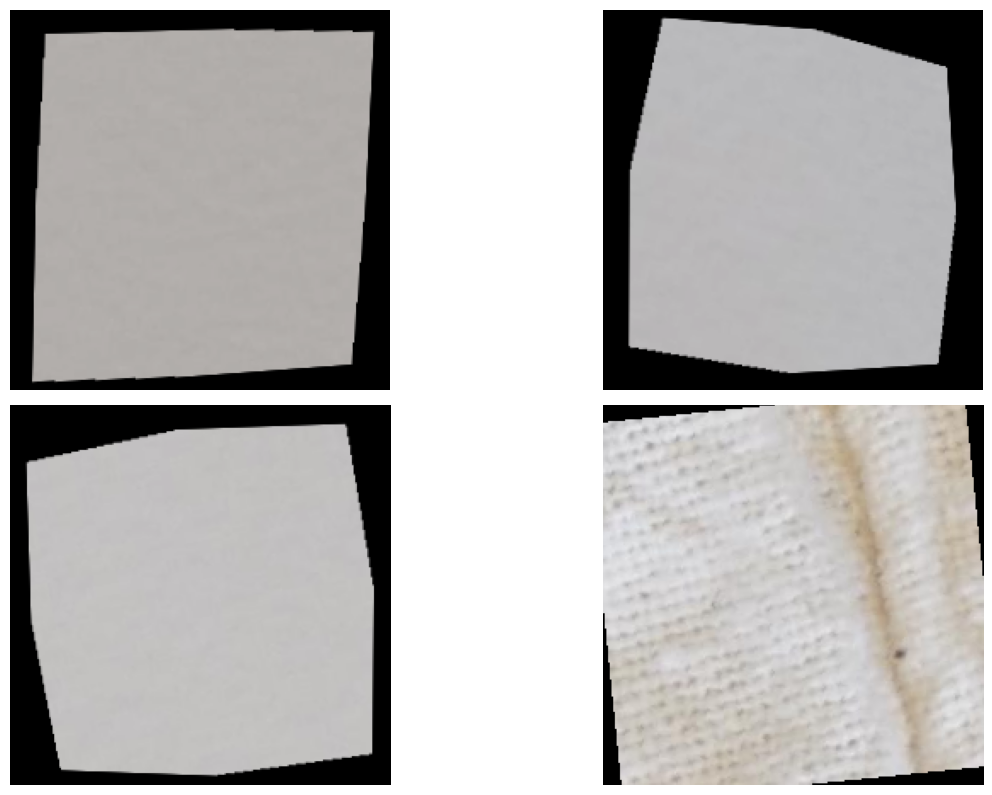

In [205]:
plot_images_from_dataset(*next(iter(augmented_train_loader)))

In [ ]:
import skimage.filters

camera = skimage.data.camera()
camera_blur = skimage.filters.gaussian(camera, sigma=3)

plt.figure(figsize=(12, 7))
plt.imshow(camera_blur, cmap='gray')
plt.title('Blurred image')
plt.show()

In [206]:
torch.manual_seed(42)

model = Net()
# model.freeze_feature_layers()

learning_rate = 0.0001

criterion = nn.CrossEntropyLoss()
metrics = {'ACC': acc, 'F1-weighted': f1}
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

N_EPOCHS =  10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
criterion.to(device)

train_cycle(model, optimizer, augmented_train_loader, val_dataloader, N_EPOCHS, device)

# save model weights
results_models_dir = 'models/'
if not os.path.exists(results_models_dir):
    os.mkdir(results_models_dir)
torch.save(model.state_dict(), results_models_dir + 'base_model_trained_on_augmented_set.pth')

c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Epoch 1/10


Evaluating: 100%|██████████| 6/6 [00:11<00:00,  1.91s/it]


Evaluated 21 images.
Train Loss: 0.6058 | Val Loss: 189.1471

Epoch 2/10


Evaluating: 100%|██████████| 6/6 [00:11<00:00,  1.89s/it]


...

Evaluated 21 images.
Train Loss: nan | Val Loss: 755.4438

Epoch 4/10


Evaluating: 100%|██████████| 6/6 [00:11<00:00,  1.85s/it]


Evaluated 21 images.
Train Loss: nan | Val Loss: 797.6062

Epoch 5/10


 38%|███▊      | 8/21 [00:31<00:51,  3.98s/it]


KeyboardInterrupt: 

In [201]:
output_submission_path = 'C:/Users/sophi/image/iapr2025/project/prediction/aug_submission.csv'
# predict_and_create_submission(model, sample_submission_path, output_submission_path)
predict_and_create_submission(
    sample_submission_path,
    output_submission_path,
    model_weights_path='C:/Users/sophi/image/iapr2025/project/models/base_model_trained_on_augmented_set.pth',
    classes=classes,  # List of class names
    device=device,
    transform=augmented_transform_train,  # Your preprocessing pipeline
    TEST_IMAGE_DIR=TEST_IMAGE_DIR
)

c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Submission saved to C:/Users/sophi/image/iapr2025/project/prediction/aug_submission.csv


In [199]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as F

def plot_model_predictions(model, dataloader, device, classes, num_batches=1, score_threshold=0.5):
    model.eval()
    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(dataloader):
            if batch_idx >= num_batches:
                break

            images = [img.to(device) for img in images]
            outputs = model(images)

            for img, preds, target in zip(images, outputs, targets):
                img = img.cpu()
                fig, ax = plt.subplots(1, figsize=(8, 8))
                img_np = img.permute(1, 2, 0).numpy()
                img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # unnormalize
                img_np = img_np.clip(0, 1)
                ax.imshow(img_np)

                # Plot predicted boxes
                for box, label, score in zip(preds['boxes'], preds['labels'], preds['scores']):
                    if score >= score_threshold:
                        x1, y1, x2, y2 = box.cpu().numpy()
                        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                                 linewidth=2, edgecolor='lime', facecolor='none')
                        ax.add_patch(rect)
                        ax.text(x1, y1 - 10, f'{classes[label]}: {score:.2f}', color='lime', fontsize=10, weight='bold')

                # Plot ground truth boxes
                for box, label in zip(target['boxes'], target['labels']):
                    x1, y1, x2, y2 = box.cpu().numpy()
                    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
                    ax.add_patch(rect)
                    ax.text(x1, y2 + 5, f'{classes[label]} (GT)', color='red', fontsize=9)

                ax.axis('off')
                plt.title('Green = Prediction | Red = Ground Truth')
                plt.show()

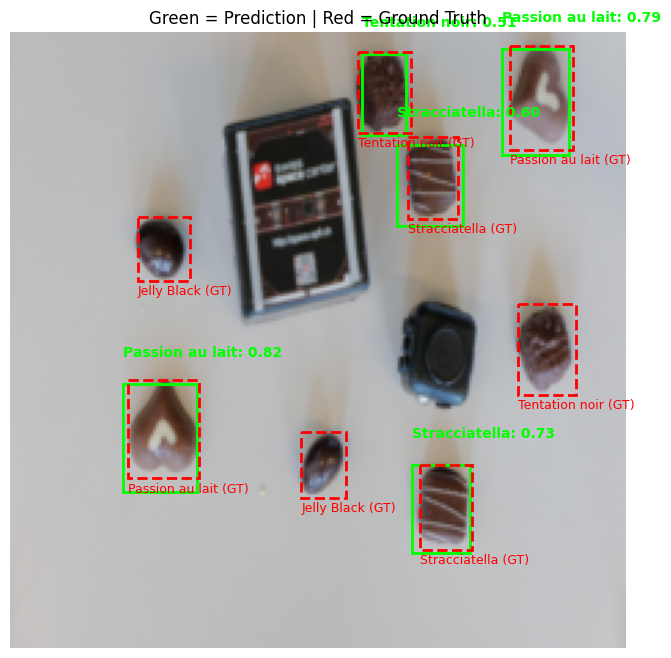

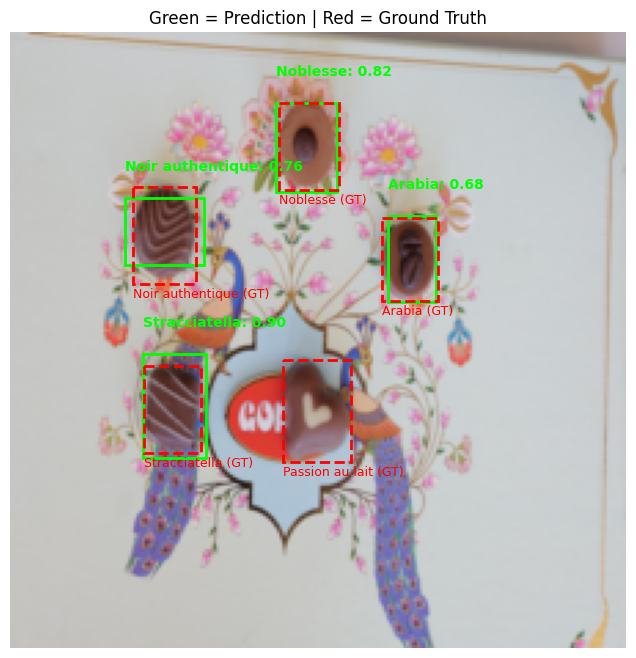

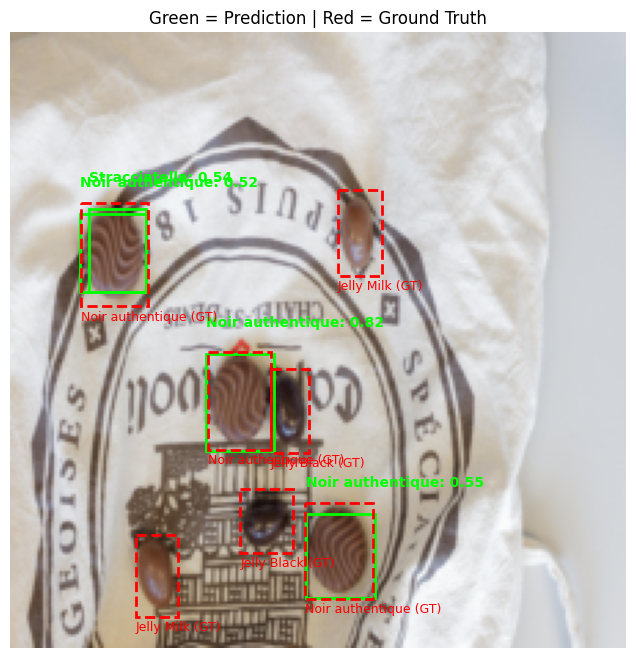

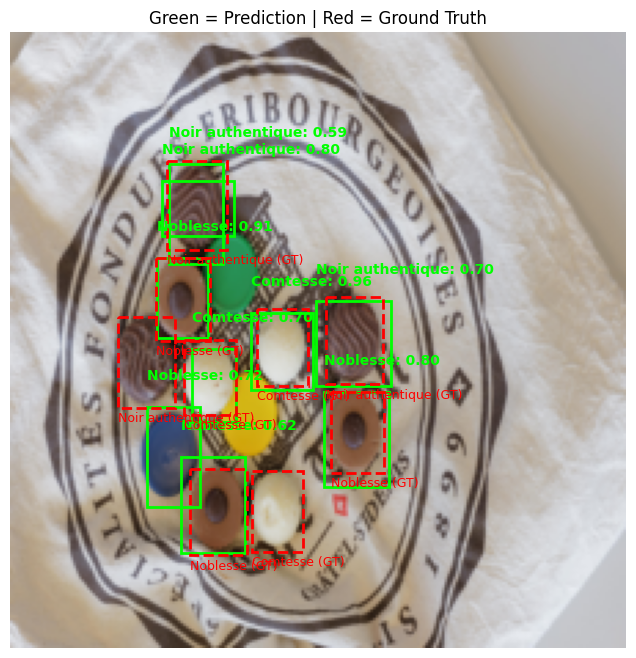

In [200]:
plot_model_predictions(model, val_dataloader, device, classes, num_batches=1, score_threshold=0.5)